# Sentiment Analysis with SVM and Neural Networks

This notebook implements Task 2 (Support Vector Machines) and Task 3 (Neural Networks) for sentiment analysis on a provided dataset.

## 1. Setup and Data Loading
First, we import the necessary libraries and load the dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Scikit-Learn imports
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.decomposition import PCA

# TensorFlow/Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, GlobalAveragePooling1D, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [2]:
# Set plotting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load dataset
# Assuming this notebook is in the sentiment_analysis folder
dataset_path = Path('sentiment_dataset.csv')
df = pd.read_csv(dataset_path)
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,1/15/2023 12:30,User123,Twitter,#Nature #Park,15,30,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,1/15/2023 8:45,CommuterX,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,1/15/2023 15:45,FitnessFan,Instagram,#Fitness #Workout,20,40,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,1/15/2023 18:20,AdventureX,Facebook,#Travel #Adventure,8,15,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,1/15/2023 19:55,ChefCook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19


## 2. Data Preprocessing for Binary Classification

We need to filter our dataset for binary classification, focusing on 'Positive' and 'Negative' sentiments. Then, we prepare the labels by encoding them into binary values (1 for Positive, 0 for Negative).

In [ ]:
df['Sentiment'] = df['Sentiment'].str.strip()

binary_df = df[df['Sentiment'].isin(['Positive', 'Negative'])].copy()
print(f"Dataset shape after filtering: {binary_df.shape}")

binary_df['Sentiment_Label'] = binary_df['Sentiment'].map({
    'Positive': 1,
    'Negative': 0
})

# Extract features (X) and target (y)
X = binary_df['Text']
y = binary_df['Sentiment_Label']

print("Class Distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Dataset shape after filtering: (49, 16)
Class Distribution:
 Sentiment_Label
1    45
0     4
Name: count, dtype: int64
Training set size: 36, Test set size: 13


## Task 2: Support Vector Machine (SVM) for Classification

### Text Vectorization (TF-IDF)
Before feeding the text to an SVM, we must convert it into numerical features. We use Term Frequency-Inverse Document Frequency (TF-IDF).

In [18]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Matrix shape: {X_train_tfidf.shape}")

TF-IDF Matrix shape: (36, 325)


### Training and Evaluating SVM Models
We will define a helper function to train the SVM model, print metrics, and plot the Confusion Matrix and ROC Curve. We evaluate two types of kernels: **Linear** and **RBF**.

In [ ]:
def train_and_evaluate_svm(kernel_type):
    print(f"\n--- Training SVM with {kernel_type.upper()} kernel ---")

    model = SVC(kernel=kernel_type, probability=True, random_state=42)
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    # Debug
    print("Unique y_test:", np.unique(y_test))
    print("Unique y_pred:", np.unique(y_pred))

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # -----------------------------
    # Safe ROC AUC
    # -----------------------------
    if len(np.unique(y_test)) > 1:
        y_prob = model.predict_proba(X_test_tfidf)[:, 1]
        roc_auc = roc_auc_score(y_test, y_prob)
        print(f"ROC AUC Score: {roc_auc:.4f}")
    else:
        y_prob = None
        roc_auc = None
        print("ROC AUC not defined (only one class in y_test)")

    # -----------------------------
    # Classification Report (FIXED)
    # -----------------------------
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=['Negative', 'Positive'],
        zero_division=0
    ))

    # -----------------------------
    # Plots
    # -----------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'], ax=ax1)
    ax1.set_title(f'Confusion Matrix (SVM {kernel_type.capitalize()})')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('Actual')

    # ROC Curve
    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        ax2.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.2f}')
        ax2.plot([0, 1], [0, 1], lw=2, linestyle='--')
        ax2.set_title(f'ROC Curve (SVM {kernel_type.capitalize()})')
        ax2.legend()
    else:
        ax2.set_title("ROC Curve not available")

    plt.tight_layout()
    plt.show()

    return model


--- Training SVM with LINEAR kernel ---
Unique y_test: [0 1]
Unique y_pred: [1]
Accuracy: 0.9231
ROC AUC Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.92      1.00      0.96        12

    accuracy                           0.92        13
   macro avg       0.46      0.50      0.48        13
weighted avg       0.85      0.92      0.89        13



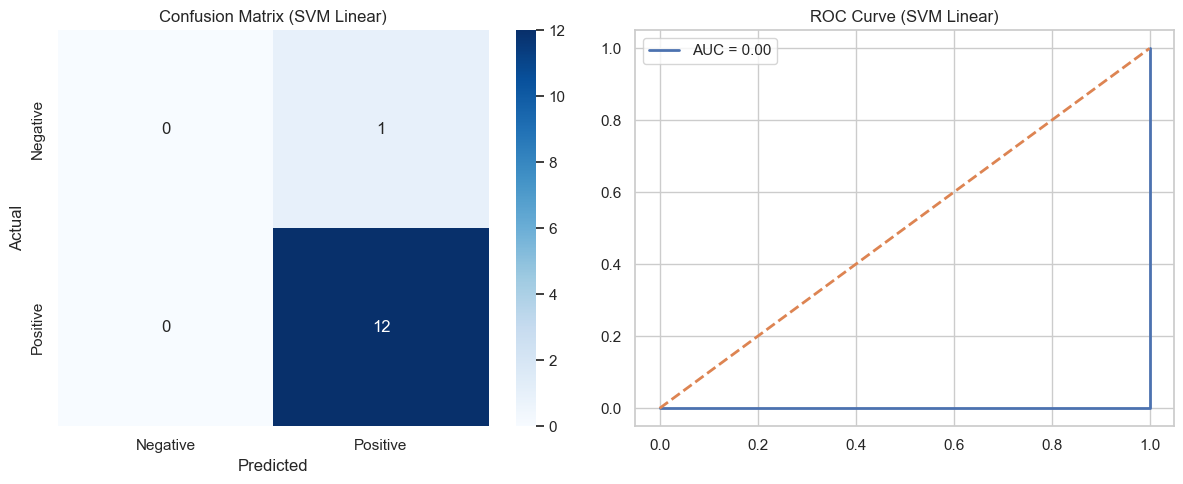

In [20]:
# Execute for Linear Kernel
svm_linear = train_and_evaluate_svm('linear')


--- Training SVM with RBF kernel ---
Unique y_test: [0 1]
Unique y_pred: [1]
Accuracy: 0.9231
ROC AUC Score: 0.0000

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         1
    Positive       0.92      1.00      0.96        12

    accuracy                           0.92        13
   macro avg       0.46      0.50      0.48        13
weighted avg       0.85      0.92      0.89        13



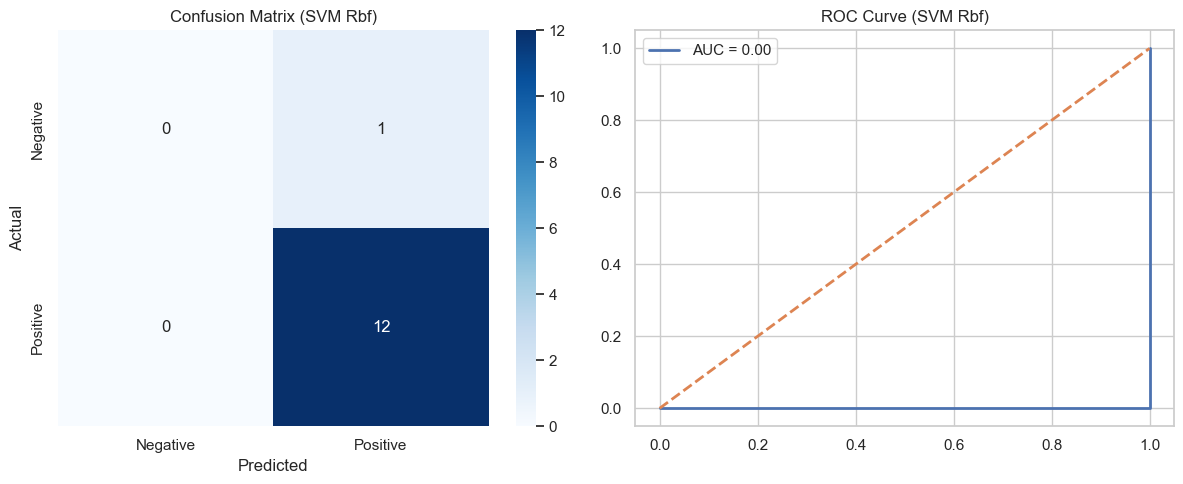

In [21]:
# Execute for RBF Kernel
svm_rbf = train_and_evaluate_svm('rbf')

### Visualizing SVM Decision Boundary
Since the TF-IDF feature space is highly dimensional, we cannot visualize the decision boundary directly. We will use Principal Component Analysis (PCA) to reduce the dimensionality to 2D for visualization purposes.

Visualizing Decision Boundary...


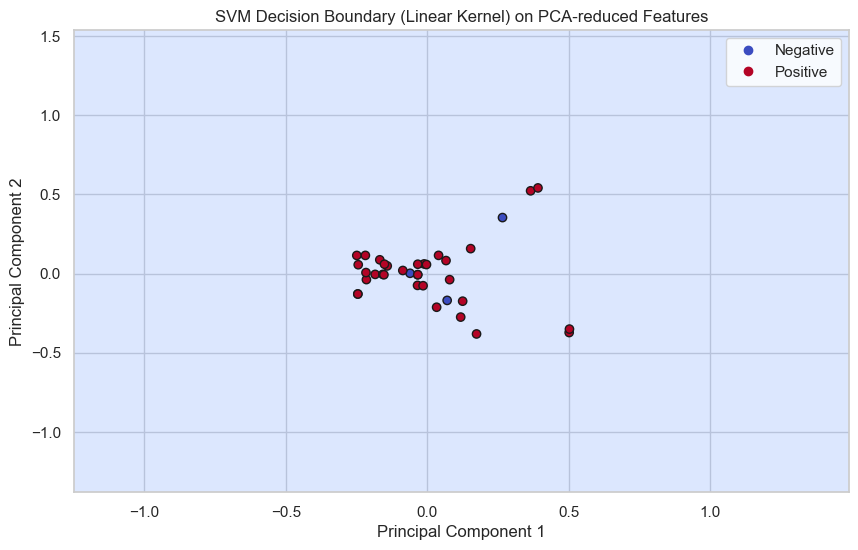

In [22]:
print("Visualizing Decision Boundary...")
# Reduce features to 2 dimensions
pca = PCA(n_components=2)
# Using a subset of training data (first 500 samples) to make the plot clean and fast to render
sample_size = min(500, X_train_tfidf.shape[0])
X_train_sample = X_train_tfidf[:sample_size]
y_train_sample = y_train[:sample_size].values

X_pca = pca.fit_transform(X_train_sample.toarray())

# Train a simplified 2D SVM on the reduced data
svm_2d = SVC(kernel='linear', C=1.0)
svm_2d.fit(X_pca, y_train_sample)

# Create a mesh grid
h = .02 
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predict the classes across the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the contour and training examples
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train_sample, cmap=plt.cm.coolwarm, edgecolors='k')
plt.title('SVM Decision Boundary (Linear Kernel) on PCA-reduced Features')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=['Negative', 'Positive'])
plt.show()

## Task 3: Neural Networks with TensorFlow/Keras

Next, we build a Feed-Forward Neural Network for the same binary sentiment classification task.

### Preprocessing for Neural Networks (Tokenization and Padding)
Unlike TF-IDF, neural networks dealing with text typically take in integer sequences where each integer corresponds to a specific word.

In [23]:
vocab_size = 10000 
embedding_dim = 16
max_length = 50 
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

# Fit tokenizer on training text
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

# Convert texts to sequences
train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

# Pad the sequences so they all have the same length
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print(f"Shape of padded training sequences: {train_padded.shape}")

Shape of padded training sequences: (36, 50)


### Building the Neural Network Architecture
We create a Sequential model with an Embedding layer to process words, followed by pooling, dense layers, and dropout for regularization.

In [24]:
model = Sequential([
    Embedding(vocab_size, embedding_dim, input_length=max_length),
    GlobalAveragePooling1D(),
    Dense(24, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Binary classification output
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 50, 16)            160000    
                                                                 
 global_average_pooling1d (  (None, 16)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense (Dense)               (None, 24)                408       
                                                                 
 dropout (Dropout)           (None, 24)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 25        
                                                                 
Total params: 160433 (626.69 KB)
Trainable params: 160433 (626.69 KB)
Non-trainable params: 0 (0.00 Byte)
______________

### Model Training
We train the model using backpropagation for a few epochs.

In [25]:
num_epochs = 10
history = model.fit(train_padded, y_train, epochs=num_epochs, validation_data=(test_padded, y_test), verbose=1)

Epoch 1/10


2/2 [==============================] - 1s 191ms/step - loss: 0.6974 - accuracy: 0.3611 - val_loss: 0.6914 - val_accuracy: 0.9231
Epoch 2/10
2/2 [==============================] - 0s 24ms/step - loss: 0.6880 - accuracy: 0.6111 - val_loss: 0.6852 - val_accuracy: 0.9231
Epoch 3/10
2/2 [==============================] - 0s 26ms/step - loss: 0.6868 - accuracy: 0.6944 - val_loss: 0.6792 - val_accuracy: 0.9231
Epoch 4/10
2/2 [==============================] - 0s 28ms/step - loss: 0.6797 - accuracy: 0.8333 - val_loss: 0.6736 - val_accuracy: 0.9231
Epoch 5/10
2/2 [==============================] - 0s 35ms/step - loss: 0.6729 - accuracy: 0.9167 - val_loss: 0.6677 - val_accuracy: 0.9231
Epoch 6/10
2/2 [==============================] - 0s 39ms/step - loss: 0.6653 - accuracy: 0.8889 - val_loss: 0.6617 - val_accuracy: 0.9231
Epoch 7/10
2/2 [==============================] - 0s 35ms/step - loss: 0.6618 - accuracy: 0.9167 - val_loss: 0.6559 - val_accuracy: 0.9231
Epoch 8/10
2/2 [========

### Evaluation and Visualization of Training History
Let's see how the model's accuracy and loss change over time on the training and validation sets.


Neural Network Final Test Accuracy: 0.9231


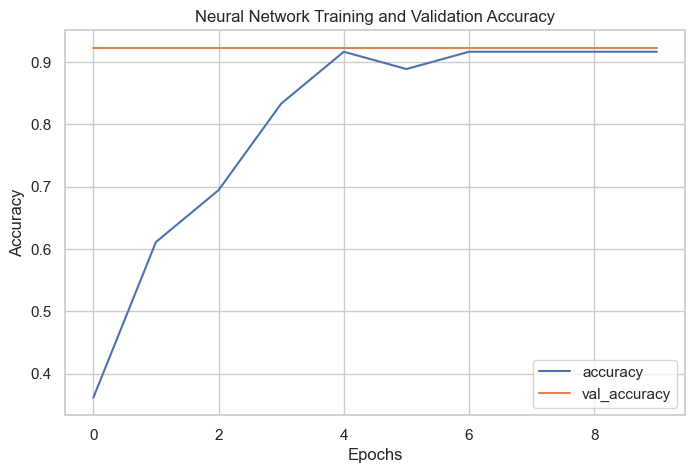

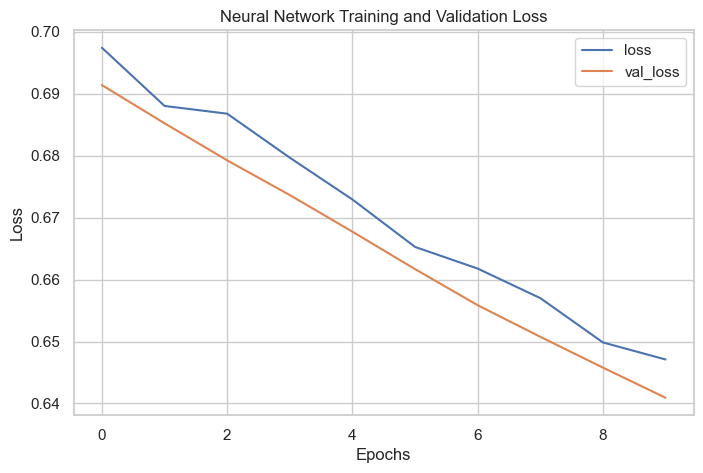

In [26]:
loss, accuracy = model.evaluate(test_padded, y_test, verbose=0)
print(f"\nNeural Network Final Test Accuracy: {accuracy:.4f}")

def plot_graphs(history, string):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string.capitalize())
    plt.legend([string, 'val_'+string])
    plt.title(f'Neural Network Training and Validation {string.capitalize()}')
    plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")